# IGVF Catalog Python Client — Examples

This notebook demonstrates how to use the [IGVF Catalog Python client](https://github.com/igvf/igvf-catalog-python-client) to query the IGVF Catalog API, load results into pandas DataFrames, and create basic visualizations with matplotlib.

We use **GCK (glucokinase)** as a running example — a well-studied gene involved in glucose metabolism and associated with maturity-onset diabetes of the young (MODY).

**Prerequisites:**
```bash
pip install igvf-catalog-client pandas matplotlib
```

**Key conventions:**
- Genomic coordinates are **0-based, half-open** on the **GRCh38** (human) / **GRCm39** (mouse) reference genomes
- Pagination is **0-based** (first page is `page=0`)
- The `limit` parameter controls page size (max 500 for most endpoints)

## 1. Setup & Configuration

In [1]:
import igvf_catalog_client
from igvf_catalog_client.rest import ApiException
import pandas as pd
import matplotlib.pyplot as plt

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


In [2]:
# Create the API client with the default host
configuration = igvf_catalog_client.Configuration(
    host="https://api.catalogkg.igvf.org/api"
)

api_client = igvf_catalog_client.ApiClient(configuration)
api = igvf_catalog_client.IgvfCatalogApi(api_client)

print(f"Connected to: {configuration.host}")

Connected to: https://api.catalogkg.igvf.org/api


## 2. Looking Up a Gene

Search for GCK (glucokinase) by gene name and explore its metadata.

In [3]:
# Look up the GCK gene by name
genes = api.genes(name="GCK")

print(f"Found {len(genes)} result(s)")

gck = genes[0]
print(f"Gene: {gck.name}")
print(f"Ensembl ID: {gck.id}")
print(f"Location: {gck.chr}:{gck.start}-{gck.end}")
print(f"Type: {gck.gene_type}")
print(f"Source: {gck.source}")

Found 1 result(s)
Gene: GCK
Ensembl ID: ENSG00000106633
Location: chr7:44143212-44198170
Type: protein_coding
Source: GENCODE


In [4]:
# Load gene info into a DataFrame
genes_df = pd.DataFrame([g.to_dict() for g in genes])
genes_df

,_id,chr,start,end,gene_type,name,strand,hgnc,entrez,source,version,source_url,synonyms,collections,study_sets
0,ENSG00000106633,chr7,44143212,44198170,protein_coding,GCK,-,HGNC:4195,ENTREZ:2645,GENCODE,v43,https://ftp.ebi.ac.uk/pub/databases/gencode/Ge...,"[PNDM1, HXKP, LGLK, hexokinase type IV, glucok...",None,None


## 3. Variants Associated with a Gene

Find variants linked to GCK with significant p-values, using eQTL data.

In [5]:
# Get variants associated with GCK, filtering for significant associations
# neg_log10_pvalue="gt:5.0" means -log10(p) > 5, i.e. p < 1e-5
variants = api.variants_from_genes(
    gene_name="GCK",
    neg_log10_pvalue="gt:5.0",
    method="eQTL",
    verbose="true",
    limit=25,
    page=0,
)

print(f"Found {len(variants)} significant variant-gene associations")

Found 25 significant variant-gene associations


In [6]:
# Build a DataFrame from the results
rows = []
for v in variants:
    d = v.to_dict()
    row = {
        "label": d.get("label"),
        "source": d.get("source"),
        "method": d.get("method"),
        "biosample_term": d.get("biosample_term"),
        "effect_size": d.get("effect_size"),
        "neg_log10_pvalue": d.get("neg_log10_pvalue"),
    }
    # Extract variant info if available
    sv = d.get("sequence_variant")
    if isinstance(sv, dict):
        row["variant_id"] = sv.get("_id")
        row["rsid"] = sv.get("rsid")
        row["chr"] = sv.get("chr")
        row["pos"] = sv.get("pos")
    rows.append(row)

variants_df = pd.DataFrame(rows)
print(f"{len(variants_df)} rows")
variants_df.head(10)

25 rows


,label,source,method,biosample_term,effect_size,neg_log10_pvalue,variant_id,rsid,chr,pos
0,eQTL,EBI,eQTL,ontology_terms/UBERON_0000473,-0.346628,7.934581,NC_000007.14:44127030:T:C,[rs2971685],chr7,44127030
1,eQTL,EBI,eQTL,ontology_terms/UBERON_0004550,-0.564943,6.933857,NC_000007.14:43937534:C:G,[rs80107327],chr7,43937534
2,eQTL,EBI,eQTL,ontology_terms/UBERON_0002046,0.378205,8.221092,NC_000007.14:44192286:T:C,[rs6975024],chr7,44192286
3,eQTL,EBI,eQTL,ontology_terms/UBERON_0001159,-0.319077,6.916695,NC_000007.14:44136187:C:T,[rs9791709],chr7,44136187
4,eQTL,EBI,eQTL,ontology_terms/UBERON_0002046,0.348608,7.538815,NC_000007.14:44212591:TGTG:TG,[rs3840674],chr7,44212591
5,eQTL,EBI,eQTL,ontology_terms/UBERON_0001013,-0.340163,10.238204,NC_000007.14:44134359:C:A,[rs11975874],chr7,44134359
6,eQTL,EBI,eQTL,ontology_terms/UBERON_0000992,-0.486137,7.029467,NC_000007.14:44101287:A:G,[rs12537297],chr7,44101287
7,eQTL,EBI,eQTL,ontology_terms/UBERON_0001159,-0.325059,6.547254,NC_000007.14:44144803:C:T,[rs13306388],chr7,44144803
8,eQTL,EBI,eQTL,ontology_terms/UBERON_0001159,-0.319077,6.916695,NC_000007.14:44137591:A:G,[rs17136076],chr7,44137591
9,eQTL,EBI,eQTL,ontology_terms/UBERON_0001159,-0.336612,7.785636,NC_000007.14:44146205:C:G,[rs887687],chr7,44146205


### Pagination

The API returns paginated results. Use `page` and `limit` to iterate through pages.

In [7]:
# Example: paginate through results
all_rows = []
page = 0
page_size = 100

while True:
    results = api.variants_from_genes(
        gene_name="GCK",
        neg_log10_pvalue="gt:5.0",
        method="eQTL",
        limit=page_size,
        page=page,
    )
    if not results:
        break
    all_rows.extend([r.to_dict() for r in results])
    print(f"Page {page}: {len(results)} results")
    if len(results) < page_size:
        break
    page += 1

print(f"\nTotal: {len(all_rows)} results across {page + 1} page(s)")

Page 0: 68 results

Total: 68 results across 1 page(s)


## 4. Manhattan-Style Plot

Visualize variant associations by genomic position vs statistical significance.

In [9]:
# Fetch variant-gene associations across a region near GCK (chr7)
region_variants = api.genes_from_variants(
    region="chr7:44190000-44200000",
    verbose="true",
    limit=500,
    page=0,
)

print(f"Found {len(region_variants)} variant-gene associations in region")

Found 95 variant-gene associations in region


In [10]:
# Extract positions and p-values for plotting
plot_data = []
for v in region_variants:
    d = v.to_dict()
    sv = d.get("sequence_variant")
    pval = d.get("neg_log10_pvalue")
    if isinstance(sv, dict) and pval is not None:
        pos = sv.get("pos")
        if pos is not None:
            plot_data.append({"pos": pos, "neg_log10_pvalue": float(pval)})

plot_df = pd.DataFrame(plot_data)
print(f"{len(plot_df)} variants with position and p-value data")

95 variants with position and p-value data


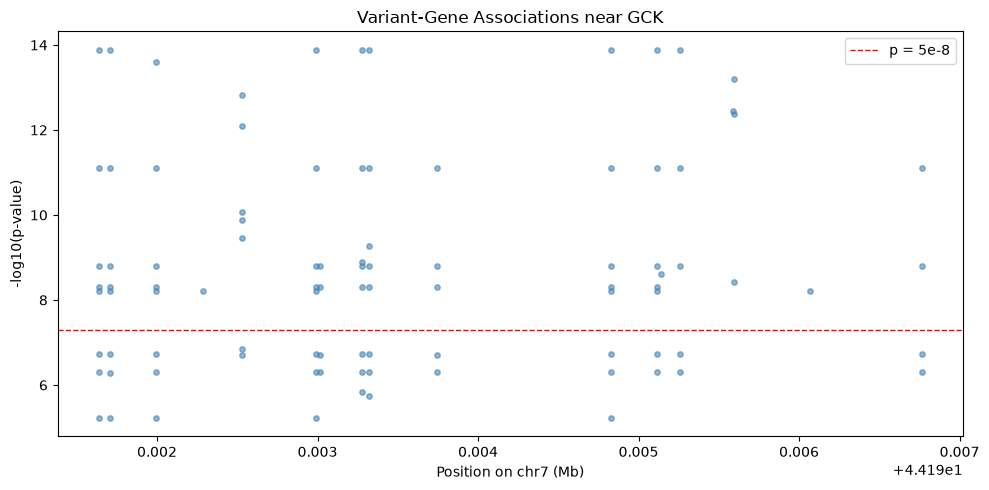

In [11]:
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.scatter(
        plot_df["pos"] / 1e6,  # convert to Mb
        plot_df["neg_log10_pvalue"],
        alpha=0.6,
        s=15,
        color="steelblue",
    )

    # Genome-wide significance line: -log10(5e-8) ≈ 7.3
    ax.axhline(y=7.3, color="red", linestyle="--", linewidth=1, label="p = 5e-8")

    ax.set_xlabel("Position on chr7 (Mb)")
    ax.set_ylabel("-log10(p-value)")
    ax.set_title("Variant-Gene Associations near GCK")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")

## 5. Regulatory Elements in a Genomic Region

Find candidate cis-regulatory elements (cCREs) near GCK.

In [12]:
# Query regulatory elements near GCK on chr7
elements = api.genomic_elements(
    region="chr7:44190000-44200000",
    limit=100,
    page=0,
)

print(f"Found {len(elements)} genomic elements in region")

Found 100 genomic elements in region


In [13]:
# Load into a DataFrame
elements_df = pd.DataFrame([e.to_dict() for e in elements])

if not elements_df.empty:
    print(f"Element types found:")
    print(elements_df["source_annotation"].value_counts())
    print()
    elements_df[["chr", "start", "end", "source_annotation", "type", "source"]].head(10)
else:
    print("No elements found.")

Element types found:
source_annotation
intergenic                                      87
dELS: distal Enhancer-like signal                6
enhancer                                         4
TF: TF binding                                   1
CA: chromatin accessible                         1
CA-CTCF: chromatin accessible + CTCF binding     1
Name: count, dtype: int64



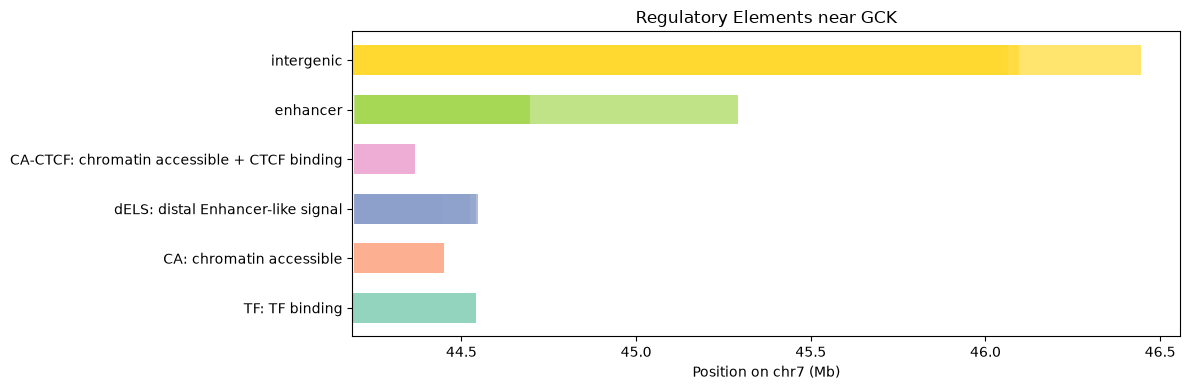

In [14]:
# Visualize element positions by annotation type
if not elements_df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))

    annotations = elements_df["source_annotation"].unique()
    colors = plt.cm.Set2.colors
    color_map = {a: colors[i % len(colors)] for i, a in enumerate(annotations)}

    for _, row in elements_df.iterrows():
        ann = row["source_annotation"]
        ax.barh(
            ann,
            (row["end"] - row["start"]) / 1e3,  # width in kb
            left=row["start"] / 1e6,  # position in Mb
            height=0.6,
            color=color_map.get(ann, "gray"),
            alpha=0.7,
        )

    ax.set_xlabel("Position on chr7 (Mb)")
    ax.set_title("Regulatory Elements near GCK")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")

## 6. Gene–Element Associations

Find which genes are linked to regulatory elements in a region.

In [15]:
# Find gene-element associations for regulatory elements near GCK
gene_elements = api.genes_from_genomic_elements(
    region="chr7:44190000-44200000",
    verbose="true",
    limit=25,
    page=0,
)

print(f"Found {len(gene_elements)} gene-element associations")

Found 25 gene-element associations


In [16]:
# Explore the associations
rows = []
for ge in gene_elements:
    d = ge.to_dict()
    row = {
        "source": d.get("source"),
        "method": d.get("method"),
        "biosample_term": d.get("biosample_term"),
    }
    gene = d.get("gene")
    if isinstance(gene, dict):
        row["gene_name"] = gene.get("name")
        row["gene_id"] = gene.get("_id")
    elem = d.get("genomic_element")
    if isinstance(elem, dict):
        row["element_name"] = elem.get("name")
        row["element_type"] = elem.get("source_annotation")
    rows.append(row)

ge_df = pd.DataFrame(rows)
if not ge_df.empty:
    print(f"Genes linked to elements in this region:")
    if "gene_name" in ge_df.columns:
        print(ge_df["gene_name"].value_counts())
    print()
    ge_df.head(10)
else:
    print("No gene-element associations found.")

Genes linked to elements in this region:
gene_name
CAMK2B    10
YKT6       8
GCK        5
MYL7       2
Name: count, dtype: int64



## 7. Coding Variant Scores

Retrieve functional impact scores for coding variants in GCK.

In [17]:
# Get coding variants for GCK
coding_variants = api.coding_variants_from_genes(
    gene_name="GCK",
    limit=100,
    page=0,
)

print(f"Found {len(coding_variants)} coding variant entries")

Found 25 coding variant entries


In [ ]:
# Each result has a protein_change and associated variants with scores
# Structure: protein_change.{hgvsp, aapos, ref, alt, ...}
#            variants[].variant.{chr, pos, rsid, spdi, ...}
#            variants[].scores[].{method, score, source_url}
rows = []
for cv in coding_variants:
    d = cv.to_dict()
    pc = d.get("protein_change", {})
    for var_entry in d.get("variants", []) or []:
        var_info = var_entry.get("variant", {}) if isinstance(var_entry, dict) else {}
        scores = var_entry.get("scores", []) if isinstance(var_entry, dict) else []
        for sc in scores:
            rows.append({
                "hgvsp": pc.get("hgvsp") if isinstance(pc, dict) else None,
                "aapos": pc.get("aapos") if isinstance(pc, dict) else None,
                "ref_aa": pc.get("ref") if isinstance(pc, dict) else None,
                "alt_aa": pc.get("alt") if isinstance(pc, dict) else None,
                "chr": var_info.get("chr"),
                "pos": var_info.get("pos"),
                "rsid": var_info.get("rsid"),
                "spdi": var_info.get("spdi"),
                "method": sc.get("method") if isinstance(sc, dict) else None,
                "score": sc.get("score") if isinstance(sc, dict) else None,
            })

cv_df = pd.DataFrame(rows)
print(f"{len(cv_df)} variant-score rows")
cv_df.head(10)

In [ ]:
# Plot score distributions by method
if not cv_df.empty:
    methods = cv_df["method"].dropna().unique()
    fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 4), squeeze=False)

    for ax, method in zip(axes[0], methods):
        method_scores = cv_df.loc[cv_df["method"] == method, "score"].dropna()
        ax.hist(method_scores, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.set_title(f"{method} Scores for GCK\n(n={len(method_scores)})")

    plt.tight_layout()
    plt.show()
else:
    print("No coding variant score data available.")

## 8. QTLs for a Gene

Query expression and splicing QTLs (eQTLs, sQTLs) associated with GCK.

In [ ]:
# Fetch QTL data for GCK
qtls = api.qtls(
    gene_name="GCK",
    limit=50,
    page=0,
)

print(f"Found {len(qtls)} QTL records")

In [ ]:
# Load QTLs into a DataFrame
rows = []
for q in qtls:
    d = q.to_dict()
    row = {
        "method": d.get("method"),
        "source": d.get("source"),
        "biological_context": d.get("biological_context"),
        "neg_log10_pvalue": d.get("neg_log10_pvalue"),
        "effect_size": d.get("effect_size"),
    }
    variant = d.get("variant")
    if isinstance(variant, dict):
        row["variant_id"] = variant.get("_id")
        row["rsid"] = variant.get("rsid")
    rows.append(row)

qtl_df = pd.DataFrame(rows)
print(f"{len(qtl_df)} rows")

if not qtl_df.empty:
    print(f"\nQTL methods:")
    print(qtl_df["method"].value_counts())
    print(f"\nBiological contexts:")
    print(qtl_df["biological_context"].value_counts().head())
    print()
    qtl_df.head(10)

## 9. Error Handling

The client raises `ApiException` for HTTP errors. Here's how to handle them.

In [ ]:
from igvf_catalog_client.rest import ApiException

try:
    # This will fail — region format requires chr:start-end
    api.genes(region="invalid_region")
except ApiException as e:
    print(f"Status: {e.status}")
    print(f"Reason: {e.reason}")
    print(f"Body: {e.body}")